# Analyse d'Image - Code Report by Selahiye Aras

## Organisation of the report:
1. The code with description
2. Choice of parameters
3. Some results and remarks
4. Difficulties Encountered along the way

## 1.The code described

We want to automate the process of counting some biological cells contained in a tif image. In order to do so we will use the ImageJ software with all the Fiji plugins installed. We have the following image as one of the 16 image series of the tif file:


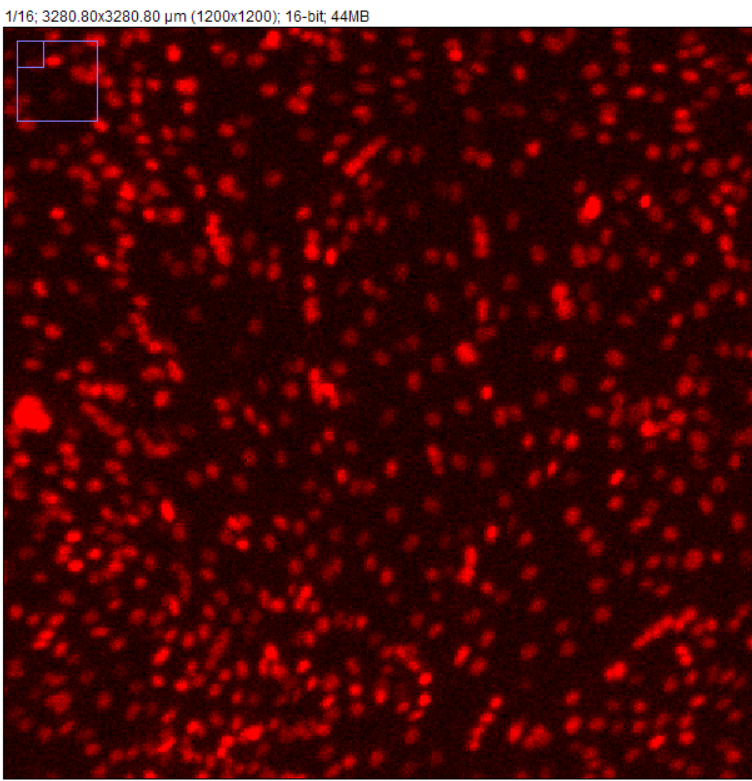

In [3]:
import base64
from IPython.display import display, HTML

# Read image file and encode it in Base64
with open("1.PNG", "rb") as image_file:
    encoded_image_data = base64.b64encode(image_file.read()).decode("utf-8")

# Construct HTML code for displaying the image
html_code = f'<img src="data:image/png;base64,{encoded_image_data}" alt="Image">'

# Display the HTML code
display(HTML(html_code))

We want to work on a copy of this stack of images as we don't want to anternate the original data by accident. Hence we duplicate the stack at first. As we want to obtain a black and white binary image upon which some operations are going to be applied, we start by augmenting the contrast of the image then applying MakeBinary Command. To generate an optional list of threshold values for further investigation we can enclose "calculate black list" when running the Make Binary command.

In [34]:
%%capture
'''// Duplicate the image
run("Duplicate...", "title=noyauxCopy.tif duplicate");

// Enhance Contrast
run("Enhance Contrast...", "saturated=0.35 normalize equalize");

// Make Binary
run("Make Binary", "calculate black list");'''

At the end of this primary process we obtain a black and white image. We can nevertheless observe that some touching particles appear as one so we need further processing before doing any counting. We can apply "erode" and "dilate" functions one after the other to get rid of noise pixels and solitary artefacts. 

Then we may run the "Watershed" function in binary, to disects objects that has clear circularity and appears to be one on the image but are separete in reality. This method finds the centre of each object (using a morphological erode operation), then calculates a distance map from the object centre points to the edges of the objects, then fills that “topological map” with imaginary water. Where 2 “Watersheds” meet, it builds a dam to separate them. So that during the next phase we get a more exact count of particles. The imj macro as javascript is given bellow:

In [33]:
%%capture
'''// Erode
run("Erode", "stack");

// Dilate
run("Dilate", "stack");

// Watershed
run("Watershed", "stack");
'''

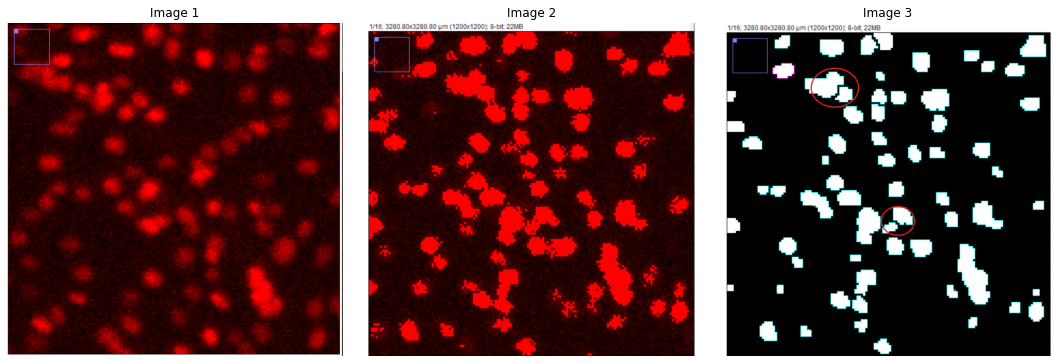

In [10]:
#Hide code cell input

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the paths to your images
image_paths = ["2_1.PNG", "2_2.PNG", "2_3.PNG"]

# Create subplots with the number of images
fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 5))  # Adjust figsize as needed

# Iterate through images and display them as subfigures
for i, path in enumerate(image_paths):
    img = mpimg.imread(path)
    axes[i].imshow(img)
    axes[i].axis('off')  # Turn off axis labels and ticks
    axes[i].set_title(f"Image {i+1}")  # Set a title for each subfigure

# Adjust layout
plt.tight_layout()

Here in the figure shown above we can see the side by side visual comparison on a zoomed-in cell image at different processing levels. The first one is the original image, the second one is the contrasted one and the last is obtained after being subjected to all methods described untill now with Watershed included. We can see that some particles that were not visible in the contrasted image is clearly discernable in the image 3 (encircled with red). And although some number of particles that are overlaping and just bearly visible in their separate caracteristic to the human eye are lost in translation, some are recovered via Watershed.

We then proceeded to run the method "Analyze Particle" in order to count the individual particles. After that the treated image, the count data the threshold values the ROI window and the Individual particle information table were outputed. As we were only interested in the countings, the thresholds and optionaly the particles's information, we save them individually, and close some windows(this part can be ruled out depending on the user's desire). In the following, is a snipet of the macro code:

In [32]:
%%capture
'''// Analyze Particles
run("Analyze Particles...", "size=0.20-Infinity circularity=0.30-1.00 show=[Bare Outlines] display exclude include summarize overlay add composite stack");
// Save the thresholdings as Text Image
selectWindow("Log");
saveAs("Text", directoryPath + "Thresholdings.txt");

// Save individual particle information
saveAs("Results", directoryPath + "IndividualParticles.csv");

// Save the drawing as Tiff
saveAs("Tiff", directoryPath + "Drawing of noyauxCopy.tif");
close();
// Close the original image
run("Close");
// Close the duplicate image
close();'''

## 2.Choices of parameters

After setting the size to 0.2-Infinity and the circularity to 0.3-1.00 with showing only the outlines of particles, one can overlay one image from the slack on top of the original image to see if the overlapping was satisfactory or not. To jugement we feel that the size paramter can be put to 0.1-Infinity but not below that.

## 3.Some results and remarks

First of all let's appreciate one of the 16 the resulting cell image, provided bellow:


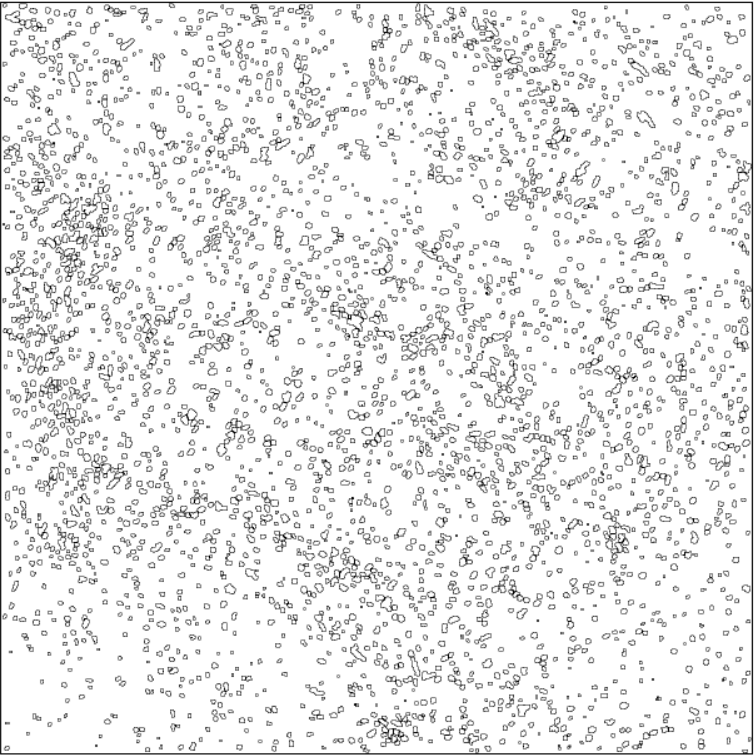

In [4]:
import base64
from IPython.display import display, HTML

# Read image file and encode it in Base64
with open("drawingCells.PNG", "rb") as image_file:
    encoded_image_data = base64.b64encode(image_file.read()).decode("utf-8")

# Construct HTML code for displaying the image
html_code = f'<img src="data:image/png;base64,{encoded_image_data}" alt="Image">'

# Display the HTML code
display(HTML(html_code))


The following Table is the output of the procedure that we have run on ImageJ


Slice	Count	Total Area	Average Size	%Area
1	4055	2573504.99	634.65	23.909
2	3534	1309954.193	370.672	12.17
3	3465	1306007.514	376.914	12.133
4	3361	1309617.829	389.651	12.167
5	3327	1352246.467	406.446	12.563
6	3190	1266720.1	397.091	11.768
7	3059	1254439.046	410.081	11.654
8	2986	1252458.232	419.443	11.636
9	2933	1276399.932	435.186	11.858
10	2929	1259424.719	429.985	11.701
11	2838	1217498.712	428.999	11.311
12	2709	1165683.577	430.3	10.83
13	2737	1199619.051	438.297	11.145
14	2618	1154336.868	440.923	10.724
15	2652	1149545.541	433.464	10.68
16	2512	1086705.11	432.606	10.096
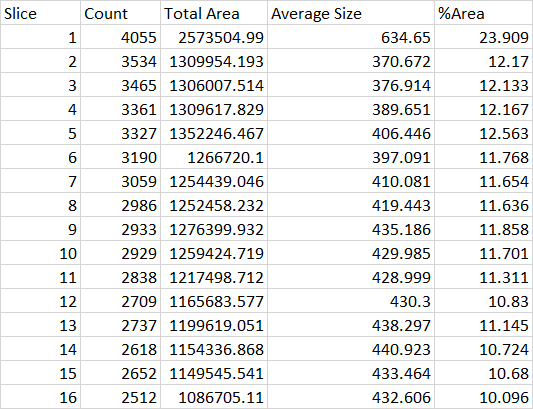

Toggle code

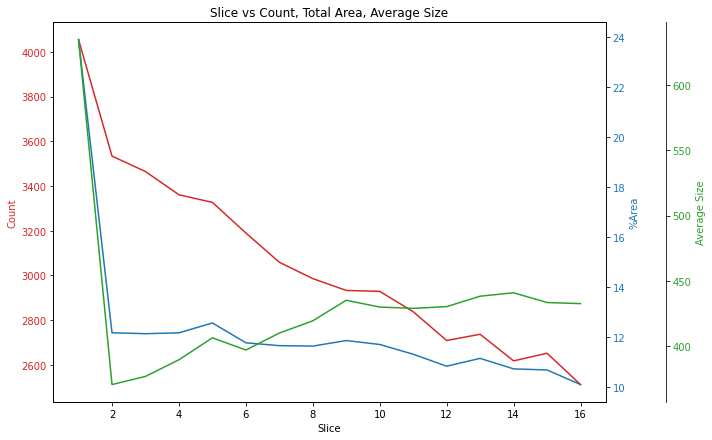

In [1]:

from IPython.display import display
from IPython.display import HTML
import IPython.core.display as di # Example: di.display_html('<h3>%s:</h3>' % str, raw=True)

# This line will hide code by default when the notebook is exported as HTML
di.display_html('<script>jQuery(function() {if (jQuery("body.notebook_app").length == 0) { jQuery(".input_area").toggle(); jQuery(".prompt").toggle();}});</script>', raw=True)

# This line will add a button to toggle visibility of code blocks, for use with the HTML export version
di.display_html('''<button onclick="jQuery('.input_area').toggle(); jQuery('.prompt').toggle();">Toggle code</button>''', raw=True)

import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame 
data = {'Slice': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
        'Count': [4055, 3534, 3465, 3361, 3327, 3190, 3059, 2986, 2933, 2929, 2838, 2709, 2737, 2618, 2652, 2512],
        'Total Area': [2573504.99, 1309954.193, 1306007.514, 1309617.829, 1352246.467, 1266720.1, 1254439.046, 1252458.232, 1276399.932, 1259424.719, 1217498.712, 1165683.577, 1199619.051, 1154336.868, 1149545.541, 1086705.11],
        'Average Size': [634.65, 370.672, 376.914, 389.651, 406.446, 397.091, 410.081, 419.443, 435.186, 429.985, 428.999, 430.3, 438.297, 440.923, 433.464, 432.606],
        '%Area': [23.909, 12.17, 12.133, 12.167, 12.563, 11.768, 11.654, 11.636, 11.858, 11.701, 11.311, 10.83, 11.145, 10.724, 10.68, 10.096]}

df = pd.DataFrame(data)

x = df['Slice']
y1 = df['Count']
y2 = df['%Area']
y3 = df['Average Size']


fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Slice')
ax1.set_ylabel('Count', color=color)
ax1.plot(x, y1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('%Area', color=color)
ax2.plot(x, y2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()  # instantiate a third axes that shares the same x-axis
color = 'tab:green'
ax3.spines['right'].set_position(('outward', 60))  # offset the third axis
ax3.set_ylabel('Average Size', color=color)
ax3.plot(x, y3, color=color)
ax3.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Slice vs Count, Total Area, Average Size')
plt.show()

In the graph above we have plotted the data of Average size, perccentage of area covered over the total surface and the nuber of paticles counted with respect  to the slice from the stack of 16 images. We can notice that the number of particles observed is decreasing as time passes (the slice number is indicative of the oberved time). This can be explaned by the fact that according to this decrease the average size of the particles is increasing, and the percentage of the area covered is just slightly decreasing. This can be interpreted as either the size of the particles are getting biger and less particles are entering the obervation plane of the objective of the camera, or that the particles are much more closer to each other and the squishing makes them look bigger as the code cannot distinguish them appart. We can also notice that the first values from the 1st slice are much greatter compared to the rest of the data set. 

The following table represent the automatically outputed threshold values:

In [7]:
from IPython.display import display
from IPython.display import HTML
import IPython.core.display as di # Example: di.display_html('<h3>%s:</h3>' % str, raw=True)

# This line will hide code by default when the notebook is exported as HTML
di.display_html('<script>jQuery(function() {if (jQuery("body.notebook_app").length == 0) { jQuery(".input_area").toggle(); jQuery(".prompt").toggle();}});</script>', raw=True)

# This line will add a button to toggle visibility of code blocks, for use with the HTML export version
di.display_html('''<button onclick="jQuery('.input_area').toggle(); jQuery('.prompt').toggle();">Toggle code</button>''', raw=True)
import pandas as pd
# Replace 'data.txt' with the actual path to your text file
file_path = 'thresholdingStats.txt'

# Specify the delimiter (e.g., '\t' for tab-separated values, ',' for comma-separated values)
delimiter = '\t'  # Replace with the actual delimiter used in your file

# Read the text file into a DataFrame
df = pd.read_csv(file_path, delimiter=delimiter, header=None)
display(df)

Toggle code

,0
0,Thresholding method: Default
1,1: 168-474
2,2: 170-486
3,3: 171-524
4,4: 171-493
5,5: 172-537
6,6: 174-487
7,7: 176-520
8,8: 176-524
9,9: 177-526


These values represent the upper and lower threshold values used to convert the greyscale image into the binary one when appling the makeBinary method. We can see by appling "Plotprofil" method manually that they are in accordance to what we might expect. Here is a arbitrary histogram of the profil passing over some cells and empty areas for comparison.


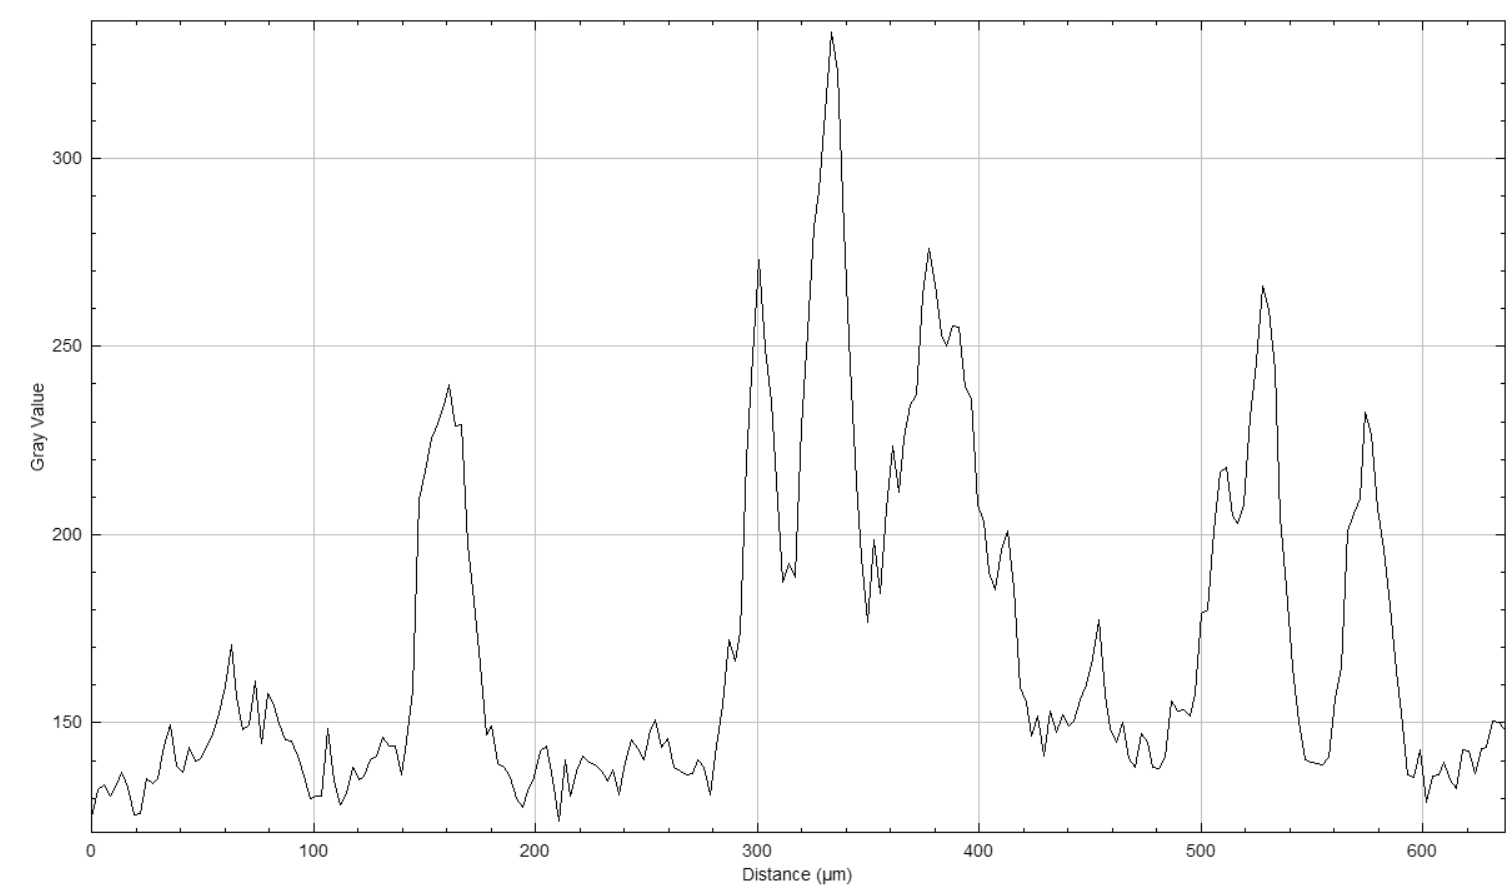

In [5]:
import base64
from IPython.display import display, HTML

# Read image file and encode it in Base64
with open("plotprofil.PNG", "rb") as image_file:
    encoded_image_data = base64.b64encode(image_file.read()).decode("utf-8")

# Construct HTML code for displaying the image
html_code = f'<img src="data:image/png;base64,{encoded_image_data}" alt="Image">'

# Display the HTML code
display(HTML(html_code))


## 4.Difficulties Encountered along the way

 We note that before attempting the anaylse with the .tif file directly we used to analyse each images as extracted from the tif to PNG using an online tool that generated greyscale images with bars over them and had to use a GaussianBlur method with sigma=2 to normalize these greyscale images, the thresholding in those primary steps where made manually by profil plotting, like the one shown before. We also used at one point Sobel algorithm to detect the edges of cells on Python before approaching the problem in a more practical way utilizing ImagJ. 

## Conclusion

We have review an automated ImageJ macro that analyzes the number of particles as well as the percentage of area they cover on the image and their respecticel average size for each of the 16 images of a stack and saves the endges of the particles as "Drawing of Copynoyaux.tif" and the results as csv files. However the application works in most cases, the cell counting results are the only data that have to be saved manually because of an unknown ImageJ inconsistency during execution.